# TP CFD
## 09/06//2026
#### Léo SENTES Mia PERROUIN

# Équation générale

$$\frac{\partial \phi}{\partial t} + \nabla \cdot (\vec{u}\, \phi) = \nabla(\Gamma \nabla(\phi))$$

En 2D :

$$\frac{\partial \phi}{\partial t} + \frac{\partial u\phi}{\partial x} + \frac{\partial v\phi}{\partial y} = \Gamma \left( \frac{\partial^2 \phi}{\partial x^2} + \frac{\partial^2 \phi}{\partial y^2} \right)$$

---

## Termes diffusifs

Intégrons sur un volume de contrôle $V_p$, avec $dV = h\,dx\,dy$ :

$$\int_{V_p} \Gamma \frac{\partial^2 \phi}{\partial x^2}\, dV + \int_{V_p} \Gamma \frac{\partial^2 \phi}{\partial y^2}\, dV$$

$$\Longleftrightarrow \int_{j-\frac{1}{2}}^{j+\frac{1}{2}} \int_{i-\frac{1}{2}}^{i+\frac{1}{2}} \Gamma \frac{\partial^2 \phi}{\partial x^2}\, h\,dx\,dy + \int_{j-\frac{1}{2}}^{j+\frac{1}{2}} \int_{i-\frac{1}{2}}^{i+\frac{1}{2}} \Gamma \frac{\partial^2 \phi}{\partial y^2}\, h\,dx\,dy$$

$$\Longleftrightarrow \Gamma h \left( \int_{j-\frac{1}{2}}^{j+\frac{1}{2}} \frac{\partial^2 \phi}{\partial x^2}\, dy + \int_{i-\frac{1}{2}}^{i+\frac{1}{2}} \frac{\partial^2 \phi}{\partial y^2}\, dx \right)$$

**Théorème de la moyenne :**

$$\Gamma h \left( \left[ \frac{\partial \phi}{\partial x} \Delta y \right]_{x_{i-\frac{1}{2}},\, y_j}^{x_{i+\frac{1}{2}},\, y_j} + \left[ \frac{\partial \phi}{\partial y} \Delta x \right]_{x_i,\, y_{j-\frac{1}{2}}}^{x_i,\, y_{j+\frac{1}{2}}} \right)$$

Discrétisation centrée ordre 2 en espace :

$$\left.\frac{\partial \phi}{\partial x}\right|_{x_{i-\frac{1}{2}},\, y_j} = \frac{\phi_{i,j} - \phi_{i-1,j}}{\Delta x}, \qquad \left.\frac{\partial \phi}{\partial x}\right|_{x_{i+\frac{1}{2}},\, y_j} = \frac{\phi_{i+1,j} - \phi_{i,j}}{\Delta x}$$

$$\left.\frac{\partial \phi}{\partial y}\right|_{x_i,\, y_{j-\frac{1}{2}}} = \frac{\phi_{i,j} - \phi_{i,j-1}}{\Delta y}, \qquad \left.\frac{\partial \phi}{\partial y}\right|_{x_i,\, y_{j+\frac{1}{2}}} = \frac{\phi_{i,j+1} - \phi_{i,j}}{\Delta y}$$

On a donc :

$$\Gamma h \left( \Delta x \cdot \frac{\phi_{i+1,j} - 2\phi_{i,j} + \phi_{i-1,j}}{\Delta x} \cdot \Delta y + \Delta y \cdot \frac{\phi_{i,j+1} - 2\phi_{i,j} + \phi_{i,j-1}}{\Delta y} \cdot \Delta x \right)$$

$$= 2h\Gamma \phi_{i,j}\left(\frac{\Delta y}{\Delta x} + \frac{\Delta x}{\Delta y}\right) + \Gamma h \left[ \frac{\Delta y}{\Delta x}\bigl(\phi_{i+1,j} + \phi_{i-1,j}\bigr) + \frac{\Delta x}{\Delta y}\bigl(\phi_{i,j+1} + \phi_{i,j-1}\bigr) \right]$$

---

## Termes convectifs

$$\int_{V_p} \left( \frac{\partial u\phi}{\partial x} + \frac{\partial v\phi}{\partial y} \right) dV \quad \text{avec } dV = h\,dx\,dy$$

$$\Longrightarrow \int_{x_{i-\frac{1}{2}}}^{x_{i+\frac{1}{2}}} \int_{y_{j-\frac{1}{2}}}^{y_{j+\frac{1}{2}}} \frac{\partial u\phi}{\partial x}\, h\,dx\,dy + \int_{x_{i-\frac{1}{2}}}^{x_{i+\frac{1}{2}}} \int_{y_{j-\frac{1}{2}}}^{y_{j+\frac{1}{2}}} \frac{\partial v\phi}{\partial y}\, h\,dx\,dy$$

$$= h \int_{y_{j-\frac{1}{2}}}^{y_{j+\frac{1}{2}}} \Bigl[ u\phi \Bigr]_{x_{i-\frac{1}{2}}}^{x_{i+\frac{1}{2}}} dy + h \int_{x_{i-\frac{1}{2}}}^{x_{i+\frac{1}{2}}} \Bigl[ v\phi \Bigr]_{y_{j-\frac{1}{2}}}^{y_{j+\frac{1}{2}}} dx = h\Delta y \Bigl[ u\phi \Bigr]_{i-\frac{1}{2}}^{i+\frac{1}{2}} + h\Delta x \Bigl[ v\phi \Bigr]_{j-\frac{1}{2}}^{j+\frac{1}{2}}$$

**Schémas Upwind :**

$$u\phi\big|_{i-\frac{1}{2},\, j} = u_{i-1,j}\,\phi_{i-1,j}, \qquad u\phi\big|_{i+\frac{1}{2},\, j} = u_{i,j}\,\phi_{i,j}$$

$$v\phi\big|_{i,\, j-\frac{1}{2}} = v_{i,j-1}\,\phi_{i,j-1}, \qquad v\phi\big|_{i,\, j+\frac{1}{2}} = v_{i,j}\,\phi_{i,j}$$

$$\Rightarrow h \left[ \Delta y \bigl( u_{i,j}\,\phi_{i,j} - u_{i-1,j}\,\phi_{i-1,j} \bigr) + \Delta x \bigl( v_{i,j}\,\phi_{i,j} - v_{i,j-1}\,\phi_{i,j-1} \bigr) \right]$$

---

## Terme temporel

$$\int_{V_p} \frac{\partial \phi}{\partial t}\, dV \quad \Longrightarrow \quad \frac{\partial \phi}{\partial t} = \frac{1}{V_p} \int_{V_p} \frac{\partial \phi}{\partial t}\, dV$$

$$\text{donc} \quad \int_{V_p} \frac{\partial \phi}{\partial t}\, dV = h\,\Delta x\,\Delta y \left.\frac{\partial \phi}{\partial t}\right|_{i,j}$$

Schéma de différence en avant d'ordre 1 :

$$\left.\frac{\partial \phi}{\partial t}\right|_{i,j} = \frac{\phi_{i,j}^{n+1} - \phi_{i,j}^{n}}{\Delta t}$$

$$\Longrightarrow \quad h\,\frac{\Delta x\,\Delta y}{\Delta t}\bigl(\phi_{i,j}^{n+1} - \phi_{i,j}^{n}\bigr)$$

---

## Assemblage final

$$h\,\frac{\Delta x\,\Delta y}{\Delta t}\bigl(\phi_{i,j}^{n+1} - \phi_{i,j}^{n}\bigr) + u_{i,j}\,\phi_{i,j}\,h\,(\Delta y + \Delta x) - u_{i-1,j}\,\phi_{i-1,j}\,\Delta y\,h - v_{i,j-1}\,\phi_{i,j-1}\,h\,\Delta x$$

$$= \Gamma h \left[ -2\phi_{i,j}\left(\frac{\Delta y}{\Delta x} + \frac{\Delta x}{\Delta y}\right) + \frac{\Delta y}{\Delta x}\bigl(\phi_{i+1,j} + \phi_{i-1,j}\bigr) + \frac{\Delta x}{\Delta y}\bigl(\phi_{i,j+1} + \phi_{i,j-1}\bigr) \right]$$

$$\Longleftrightarrow \quad \phi_{i,j}^{n+1} = \phi_{i,j}^{n} + \frac{\Delta t}{\Delta x\,\Delta y} \left( a_{i,j}\,\phi_{i,j}^{n} + a_{i-1,j}\,\phi_{i-1,j}^{n} + a_{i+1,j}\,\phi_{i+1,j}^{n} + a_{i,j+1}\,\phi_{i,j+1}^{n} + a_{i,j-1}\,\phi_{i,j-1}^{n} \right)$$

avec :

$$a_{i,j} = -2\Gamma\frac{\Delta y}{\Delta x} - 2\Gamma\frac{\Delta x}{\Delta y} + u_{i,j}\,\Delta y + v_{i,j}\,\Delta x$$

$$a_{i-1,j} = \Gamma\frac{\Delta y}{\Delta x} + u_{i-1,j}\,\Delta y \qquad a_{i+1,j} = \Gamma\frac{\Delta y}{\Delta x}$$

$$a_{i,j+1} = \Gamma\frac{\Delta x}{\Delta y} \qquad a_{i,j-1} = \Gamma\frac{\Delta x}{\Delta y} + v_{i,j-1}\,\Delta x$$

In [3]:
import numpy as np
import math
import matplotlib.pyplot as plt
# création du maillage
Lx = 1. # Length of the domain in x direction
Ly = 1. # Length of the domain in y direction
Nx = 50 # Nb of cells in x direction
Ny = Nx # Nb of cells in y direction
x = np.linspace(0,Lx,Nx+1) # Distribution of cells centers along x
y = np.linspace(0,Ly,Ny+1) # Distribution of cells centers along y

#initialisation des paramètres
dx = x[1] - x[0] # Cell size in x direction
dy = y[1] - y[0] # Cell size in y direction
gamma=10**(-3)
D=0.1 #Diametre du nuage
x_n=0.2 #composante du centre du nuage à l'état initiale
y_n=0.5 #composante du centre du nuage à l'état initiale

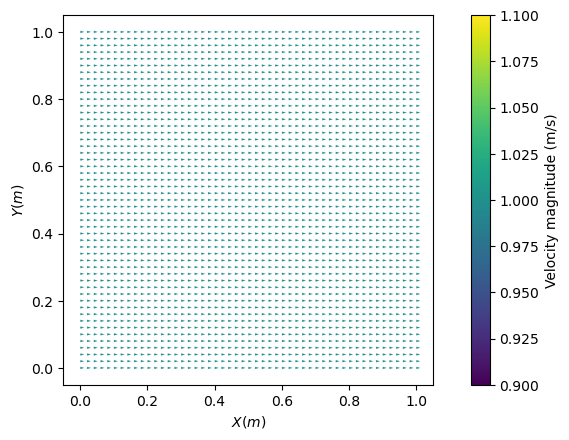

In [4]:
# Create a uniform velocity field with constant values
U0=1
V0=0
# Create the velocity field on the grid
u = U0 * np.ones((Nx+1, Ny+1))
v = V0 * np.ones((Nx+1, Ny+1))
# Compute the magnitude of the velocity field
magnitude = np.sqrt(u**2 + v**2)
# Plot the velocity field using quiver function
plt.figure()
plt.quiver(x,y,u,v,magnitude)
plt.colorbar(label='Velocity magnitude (m/s)')
plt.xlabel(r'$X(m)$')
plt.ylabel(r'$Y(m)$')
plt.axis('scaled')
plt.show()

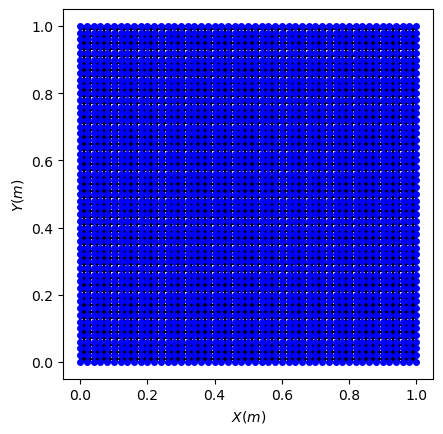

In [4]:
# Plot the mesh grid
#
plt.figure()
# Plot the grid lines
plt.plot(np.ones(Nx+1)*x[0], y, '-',color='black')
plt.plot(np.ones(Nx+1)*x[Nx], y, '-',color='black')
for i in range(1,Nx+1):
    plt.plot(np.ones(Ny+1)*x[i]- dx/2, y, '-',color='black')
plt.plot(x, np.ones(Ny+1)*y[0], '-',color='black')
plt.plot(x, np.ones(Ny+1)*y[Ny], '-',color='black')
for j in range(1,Ny+1):
    plt.plot(x, np.ones(Ny+1)*y[j]- dy/2, '-',color='black')

# Plot the cells centers
X,Y = np.meshgrid(x,y)
plt.plot(X, Y, 'o',markersize=4 ,color='blue')
plt.axis('scaled')
plt.xlabel(r'$X(m)$')
plt.ylabel(r'$Y(m)$')
plt.show()


In [5]:
#calcul du dt à partir des inégalités
dt=0
if (dx/U0<dx**2*dy**2/(2*gamma*(dx**2+dy**2))):
    dt=dx/(2*U0)
else:
    dt=dx**2*dy**2/(4*gamma*(dx**2+dy**2)) #On redivise par 2 pour être sur d'être assez petit
print(dt)

0.01


In [6]:
tfin = 0.25
N= int(tfin/dt) # indice temporel
# Initialization of the scalar field phi
phi0 = 1
phi = np.zeros((Nx+1, Ny+1,N+1))

ai1j= gamma*dy/dx
ai_1j= gamma*dy/dx + U0*dy
aij1= gamma*dx/dy
aij_1= gamma*dx/dy+ V0*dx
aij= 2*(gamma*dy/dx+gamma*dx/dy) + U0*dy + V0*dx

# Fill the scalar field with the values of the function

#initialisation à t=0
for i in range(0,Nx+1):
    for j in range(0,Ny+1):
        r=math.sqrt(abs(i*dx-x_n)**2+abs(j*dy-y_n)**2)
        if r<=D/2:
            phi[i,j,0]=phi0

for n in range (0,N):
    for i in range(1,Nx):
        phi[i,0,n]=0
        phi[i,Ny,n]=0
        for j in range(1,Ny):
            phi[Nx,j,n]=0
            phi[0,j,n]=0
            phi[i,j,n+1] = phi[i,j,n]+dt*((-1)*aij*phi[i,j,n]+ai_1j*phi[i-1,j,n]+ai1j*phi[i+1,j,n]+aij1*phi[i,j+1,n]+aij_1*phi[i,j-1,n])/(dx*dy)

In [64]:
def cfd(Lx,Ly,Nx,Ny,Tfin,gamma,D,x_n,y_n,U0,V0,phi0):
    x = np.linspace(0,Lx,Nx+1) # Distribution of cells centers along x
    y = np.linspace(0,Ly,Ny+1) # Distribution of cells centers along y

    #initialisation des paramètres
    dx = x[1] - x[0] # Cell size in x direction
    dy = y[1] - y[0] # Cell size in y direction
    #calcul du dt à partir des inégalités
    if (dx/U0<dx**2*dy**2/(2*gamma*(dx**2+dy**2))):
        dt=dx/(2*U0)
    else:
        dt=dx**2*dy**2/(4*gamma*(dx**2+dy**2)) #On redivise par 2 pour être sur d'être assez petit

    #Condition pour être sur que le calcul atteigne le temps final souhaité
    while (tfin/dt) % 1!=0:
        dt=dt-dt/100
    N= int(tfin/dt) # indice temporel
    # Initialization of the scalar field phi
    phi = np.zeros((Nx+1, Ny+1,N+1))
    
    #création des coefficients
    ai1j= gamma*dy/dx
    ai_1j= gamma*dy/dx + U0*dy
    aij1= gamma*dx/dy
    aij_1= gamma*dx/dy+ V0*dx
    aij= 2*(gamma*dy/dx+gamma*dx/dy) + U0*dy + V0*dx
    
    # Fill the scalar field with the values of the function
    
    #initialisation à t=0
    for i in range(0,Nx+1):
        for j in range(0,Ny+1):
            r=math.sqrt(abs(i*dx-x_n)**2+abs(j*dy-y_n)**2)
            if r<=D/2:
                phi[i,j,0]=phi0
    
    for n in range (0,N):
        for i in range(1,Nx):
            phi[i,0,n]=0
            phi[i,Ny,n]=0
            for j in range(1,Ny):
                phi[Nx,j,n]=0
                phi[0,j,n]=0
                phi[i,j,n+1] = phi[i,j,n]+dt*((-1)*aij*phi[i,j,n]+ai_1j*phi[i-1,j,n]+ai1j*phi[i+1,j,n]+aij1*phi[i,j+1,n]+aij_1*phi[i,j-1,n])/(dx*dy)
    return phi,N


In [65]:
def afficher (phi,N,Lx,Ly,Nx,Ny):
    x = np.linspace(0,Lx,Nx+1) # Distribution of cells centers along x
    y = np.linspace(0,Ly,Ny+1) # Distribution of cells centers along y
    # Plot the mesh grid
    plt.figure()
    # Plot the grid lines
    plt.plot(np.ones(Nx+1)*x[0], y, '-',color='black')
    plt.plot(np.ones(Nx+1)*x[Nx], y, '-',color='black')
    for i in range(1,Nx+1):
        plt.plot(np.ones(Ny+1)*x[i]- dx/2, y, '-',color='black')
    plt.plot(x, np.ones(Ny+1)*y[0], '-',color='black')
    plt.plot(x, np.ones(Ny+1)*y[Ny], '-',color='black')
    for j in range(1,Ny+1):
        plt.plot(x, np.ones(Ny+1)*y[j]- dy/2, '-',color='black')
    
    # Plot the cells centers
    X,Y = np.meshgrid(x,y)
    plt.plot(X, Y, 'o',markersize=4 ,color='blue')
    plt.axis('scaled')
    plt.xlabel(r'$X(m)$')
    plt.ylabel(r'$Y(m)$')
    plt.show()
    # Plot the scalar field phi
    plt.figure()
    # Transpose phi to match the meshgrid orientation
    # and use 'gouraud' shading for smoothness
    plt.pcolormesh(x, y, phi[:,:,N].T, shading='gouraud')
    plt.colorbar(label=r'$\phi(x,y)$') # Add a color bar to the plot
    plt.xlabel(r'$X(m)$')
    plt.ylabel(r'$Y(m)$')
    plt.axis('scaled')
    plt.show()
    # Importation of StarCCM+ values in the matrix data
    # Afin de visualiser la courbe il est necessaire de changer le chemin
    data = np.loadtxt(r"W:\TP-CFD-SENTES-MIA\distribution de C_u0=1_gamma=0_001.csv",delimiter=",",skiprows=1)
    # XY plot
    plt.figure()
    plt.plot(x,phi[:,int(Ny/2),N],label='code python')
    plt.plot(data[:,0],data[:,1],
    '-*',markersize=15,markevery=4,label="Star-CCM+")
    plt.xlabel("$x$")
    plt.ylabel("$c(x,t)$")
    plt.grid()
    plt.legend()
    plt.show()

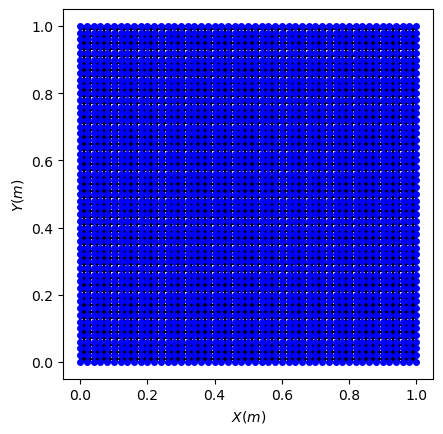

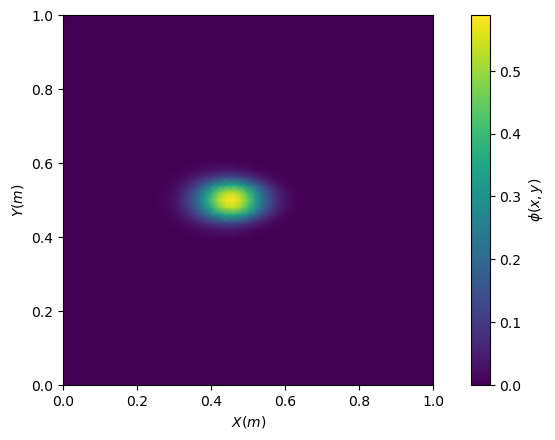

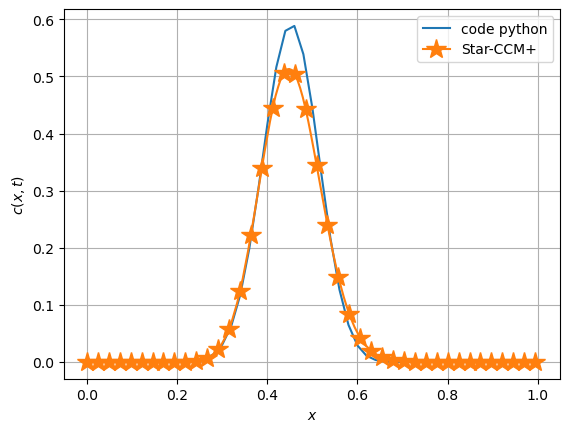

In [66]:
cfd1,N1=cfd(1,1,50,50,0.25,10**(-3),0.1,0.2,0.5,1,0,1)
afficher (cfd1,N1,1,1,50,50)

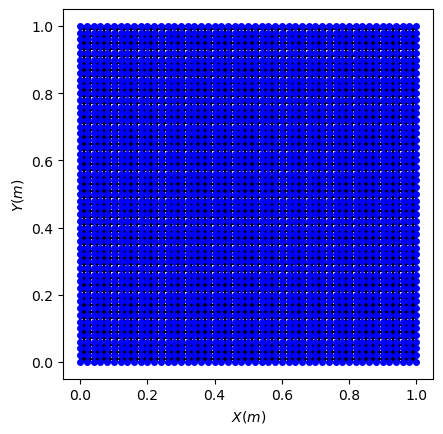

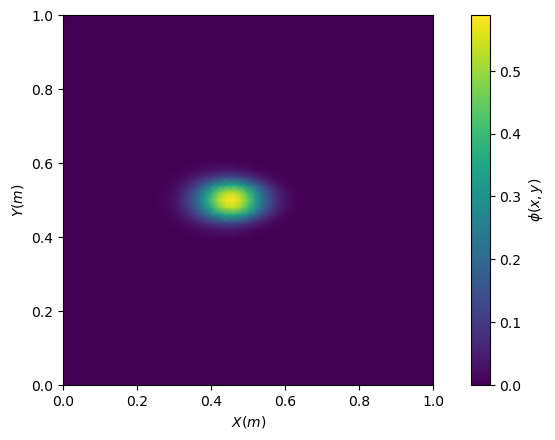

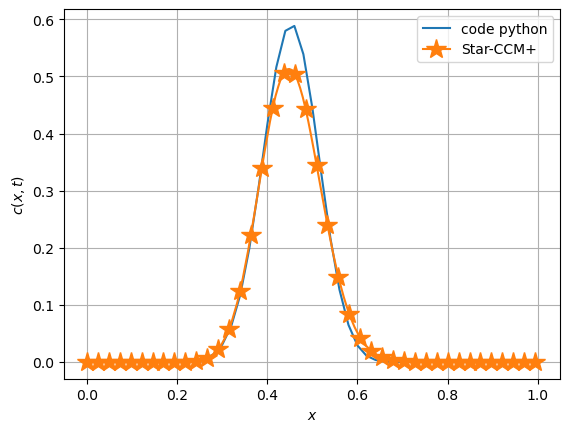

In [67]:
cfd2,N2=cfd(1,1,50,50,0.25,10**(-3),0.1,0.2,0.5,1,0,1) #essais pour se rapprocher du résultat StarCCM+ en variant le dt
afficher (cfd2,N2,1,1,50,50)

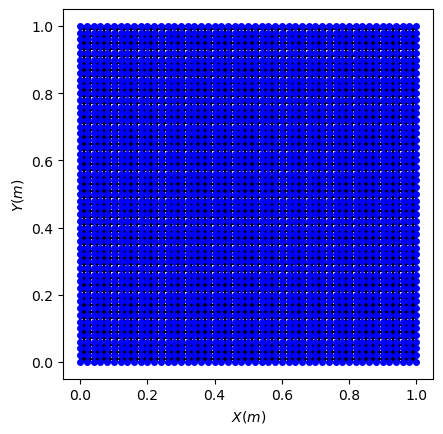

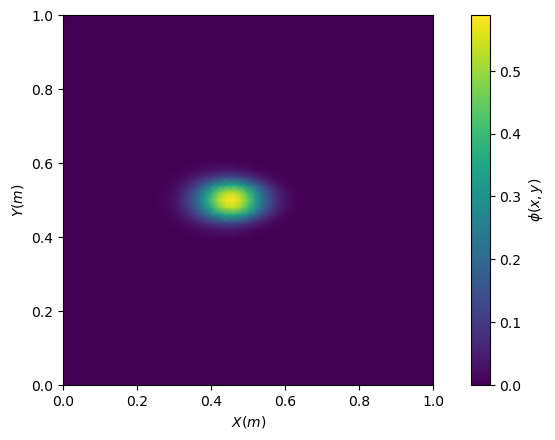

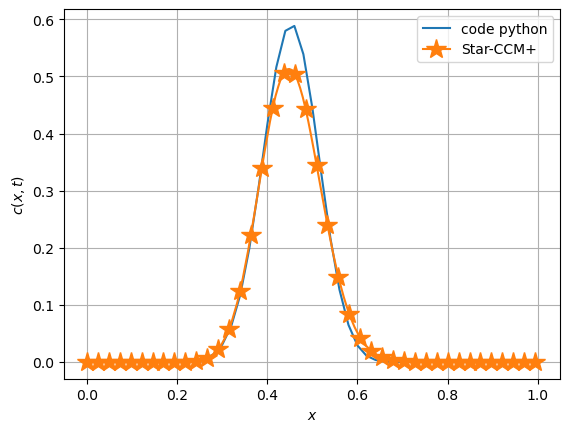

In [68]:
cfd3,N3=cfd(1,1,50,50,0.25,10**(-3),0.1,0.2,0.5,1,0,1) #essais pour se rapprocher du résultat StarCCM+ en variant le dt
afficher (cfd3,N3,1,1,50,50)

In [69]:
def cfd1(Lx,Ly,Nx,Ny,Tfin,gamma,D,x_n,y_n,U0,V0,phi0):
    x = np.linspace(0,Lx,Nx+1) # Distribution of cells centers along x
    y = np.linspace(0,Ly,Ny+1) # Distribution of cells centers along y

    #initialisation des paramètres
    dx = x[1] - x[0] # Cell size in x direction
    dy = y[1] - y[0] # Cell size in y direction
    #calcul du dt à partir des inégalités
    if (dx/U0<dx**2*dy**2/(2*gamma*(dx**2+dy**2))):
        dt=dx/(2*U0)
    else:
        dt=dx**2*dy**2/(4*gamma*(dx**2+dy**2)) #On redivise par 2 pour être sur d'être assez petit

    #Condition pour être sur que le calcul atteigne le temps final souhaité
    while (tfin/dt) % 1!=0:
        dt=dt-dt/100
    dt=0.001   
    N= int(tfin/dt) # indice temporel
    # Initialization of the scalar field phi
    phi = np.zeros((Nx+1, Ny+1,N+1))
    
    #création des coefficients
    ai1j= gamma*dy/dx
    ai_1j= gamma*dy/dx + U0*dy
    aij1= gamma*dx/dy
    aij_1= gamma*dx/dy+ V0*dx
    aij= 2*(gamma*dy/dx+gamma*dx/dy) + U0*dy + V0*dx
    
    # Fill the scalar field with the values of the function
    
    #initialisation à t=0
    for i in range(0,Nx+1):
        for j in range(0,Ny+1):
            r=math.sqrt(abs(i*dx-x_n)**2+abs(j*dy-y_n)**2)
            if r<=D/2:
                phi[i,j,0]=phi0
    
    for n in range (0,N):
        for i in range(1,Nx):
            phi[i,0,n]=0
            phi[i,Ny,n]=0
            for j in range(1,Ny):
                phi[Nx,j,n]=0
                phi[0,j,n]=0
                phi[i,j,n+1] = phi[i,j,n]+dt*((-1)*aij*phi[i,j,n]+ai_1j*phi[i-1,j,n]+ai1j*phi[i+1,j,n]+aij1*phi[i,j+1,n]+aij_1*phi[i,j-1,n])/(dx*dy)
    return phi,N

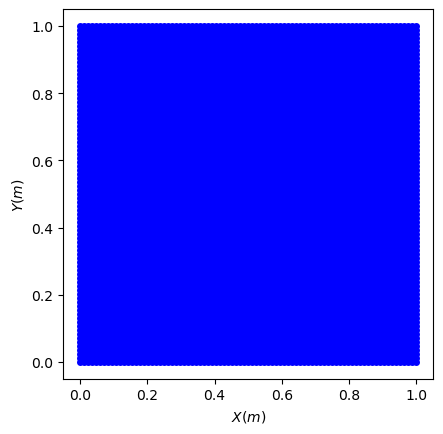

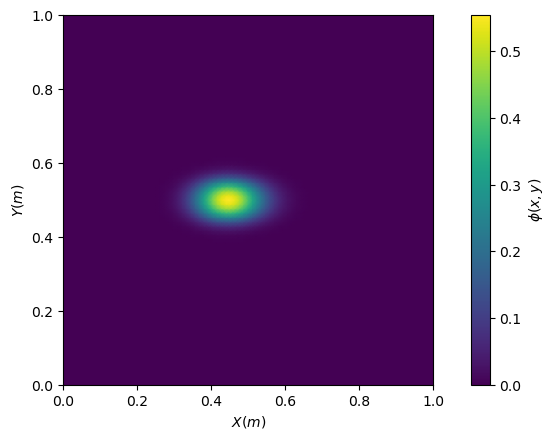

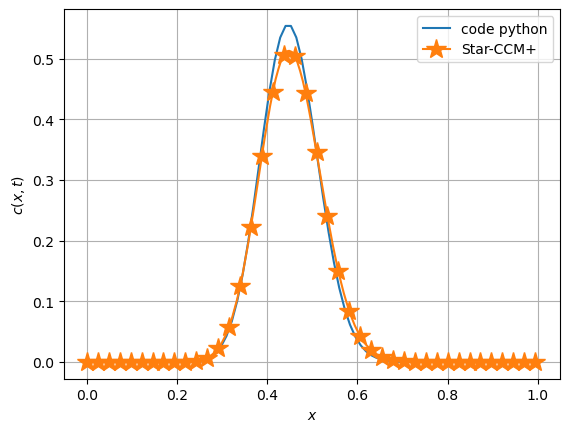

In [71]:
cfd4,N4=cfd1(1,1,84,84,0.25,10**(-3),0.1,0.2,0.5,1,0,1) #essais avec les valeurs opératoires
afficher(cfd4,N4,1,1,84,84)

In [72]:
def afficher1 (phi,N,Lx,Ly,Nx,Ny):
    x = np.linspace(0,Lx,Nx+1) # Distribution of cells centers along x
    y = np.linspace(0,Ly,Ny+1) # Distribution of cells centers along y
    # Plot the scalar field phi
    plt.figure()
    # Transpose phi to match the meshgrid orientation
    # and use 'gouraud' shading for smoothness
    plt.pcolormesh(x, y, phi[:,:,N].T, shading='gouraud')
    plt.colorbar(label=r'$\phi(x,y)$') # Add a color bar to the plot
    plt.xlabel(r'$X(m)$')
    plt.ylabel(r'$Y(m)$')
    plt.axis('scaled')
    plt.show()
    # Importation of StarCCM+ values in the matrix data
    data = np.loadtxt(r"W:\TP-CFD-SENTES-MIA\distribution de C_u0=0.5_gamma=0_001.csv",delimiter=",",skiprows=1)
    # XY plot
    plt.figure()
    plt.plot(x,phi[:,int(Ny/2),N],label='code python')
    plt.plot(data[:,0],data[:,1],
    '-*',markersize=15,markevery=4,label="Star-CCM+")
    plt.xlabel("$x$")
    plt.ylabel("$c(x,t)$")
    plt.grid()
    plt.legend()
    plt.show()

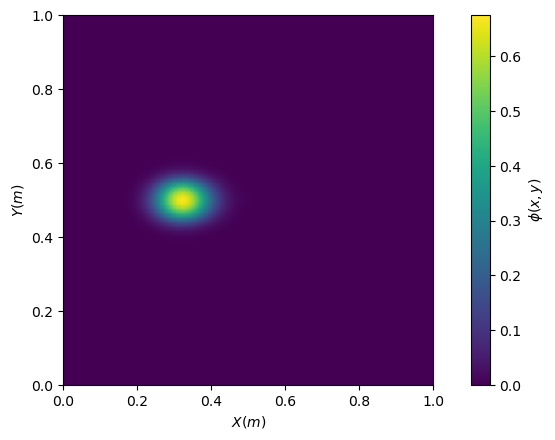

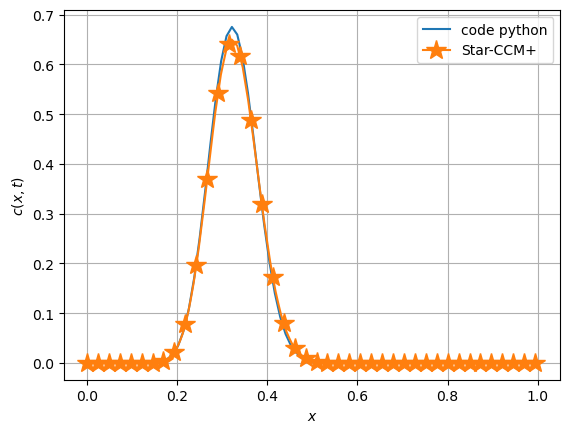

In [73]:
cfd5,N5=cfd1(1,1,84,84,0.25,10**(-3),0.1,0.2,0.5,0.5,0,1) #avec U0=0,5 m/s
afficher1(cfd5,N5,1,1,84,84)

In [74]:
def afficher2 (phi,N,Lx,Ly,Nx,Ny):
    x = np.linspace(0,Lx,Nx+1) # Distribution of cells centers along x
    y = np.linspace(0,Ly,Ny+1) # Distribution of cells centers along y
    # Plot the scalar field phi
    plt.figure()
    # Transpose phi to match the meshgrid orientation
    # and use 'gouraud' shading for smoothness
    plt.pcolormesh(x, y, phi[:,:,N].T, shading='gouraud')
    plt.colorbar(label=r'$\phi(x,y)$') # Add a color bar to the plot
    plt.xlabel(r'$X(m)$')
    plt.ylabel(r'$Y(m)$')
    plt.axis('scaled')
    plt.show()
    # Importation of StarCCM+ values in the matrix data
    data = np.loadtxt(r"W:\TP-CFD-SENTES-MIA\distribution de C_u0=2_gamma=0_001.csv",delimiter=",",skiprows=1)
    # XY plot
    plt.figure()
    plt.plot(x,phi[:,int(Ny/2),N],label='code python')
    plt.plot(data[:,0],data[:,1],
    '-*',markersize=15,markevery=4,label="Star-CCM+")
    plt.xlabel("$x$")
    plt.ylabel("$c(x,t)$")
    plt.grid()
    plt.legend()
    plt.show()

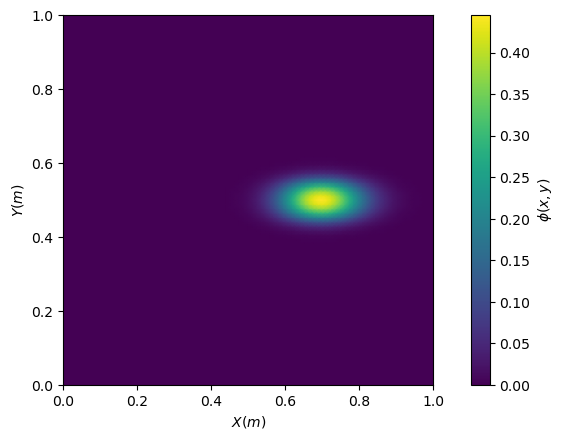

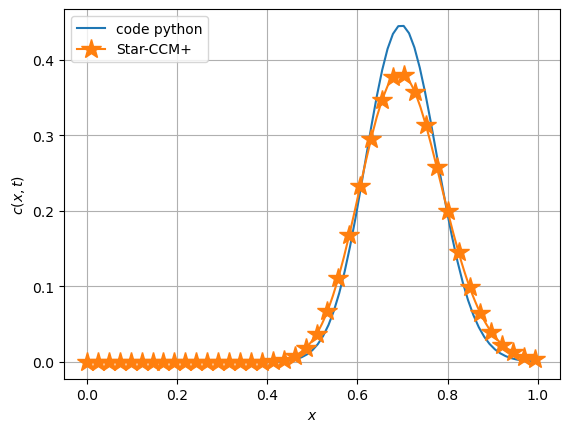

In [75]:
cfd6,N6=cfd1(1,1,84,84,0.25,10**(-3),0.1,0.2,0.5,2,0,1) #avec U0=2 m/s
afficher2(cfd6,N6,1,1,84,84)

In [86]:
def afficher3 (phi,N,Lx,Ly,Nx,Ny,phi1,phi2):
    x = np.linspace(0,Lx,Nx+1) # Distribution of cells centers along x
    y = np.linspace(0,Ly,Ny+1) # Distribution of cells centers along y
    # Importation of StarCCM+ values in the matrix data
    data = np.loadtxt(r"W:\TP-CFD-SENTES-MIA\distribution de C_u0=1_gamma=0_001.csv",delimiter=",",skiprows=1)
    data2 = np.loadtxt(r"W:\TP-CFD-SENTES-MIA\distribution de C_u0=0.5_gamma=0_001.csv",delimiter=",",skiprows=1)
    data3 = np.loadtxt(r"W:\TP-CFD-SENTES-MIA\distribution de C_u0=2_gamma=0_001.csv",delimiter=",",skiprows=1)
    # XY plot
    plt.figure()
    plt.plot(x,phi[:,int(Ny/2),N],label='u0=1')
    plt.plot(data[:,0],data[:,1],'-*',markersize=15,markevery=4,label="Star-CCM+_U0=1")
    plt.plot(x,phi1[:,int(Ny/2),N],label='u0=0.5')
    plt.plot(data2[:,0],data2[:,1],'-*',markersize=15,markevery=4,label="Star-CCM+_U0=0.5")
    plt.plot(x,phi2[:,int(Ny/2),N],label='u0=2')
    plt.plot(data3[:,0],data3[:,1],'-*',markersize=15,markevery=4,label="Star-CCM+_U0=2")
    plt.xlabel("$x$")
    plt.ylabel("$c(x,t)$")
    plt.title("Comparaison de la distribution de C entre le code et star-CCM+ pour différentes vitesses")
    plt.grid()
    plt.legend()
    plt.show()

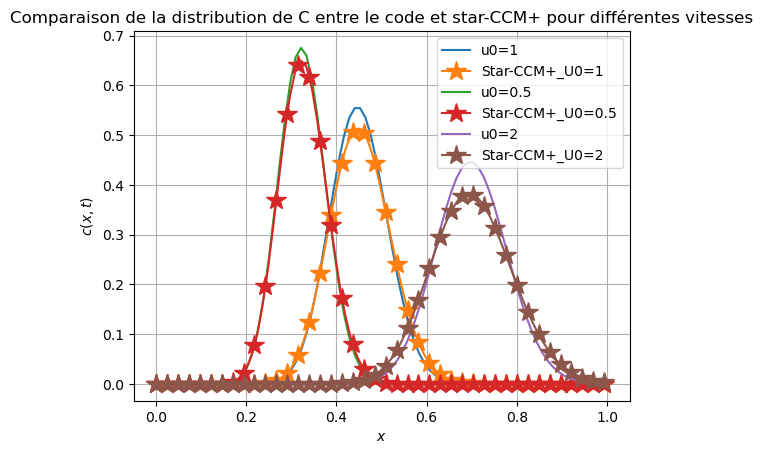

In [87]:
#affichage des 3 courbes en fonction de la vitesse
cfd4,N4=cfd1(1,1,84,84,0.25,10**(-3),0.1,0.2,0.5,1,0,1) #essais pour se rapprocher du résultat StarCCM+ en variant le dt et le maillage
cfd5,N5=cfd1(1,1,84,84,0.25,10**(-3),0.1,0.2,0.5,0.5,0,1) #avec U0=0,5 m/s
cfd6,N6=cfd1(1,1,84,84,0.25,10**(-3),0.1,0.2,0.5,2,0,1)
afficher3(cfd4,N4,1,1,84,84,cfd5,cfd6) 

In [84]:
def afficher4 (phi,N,Lx,Ly,Nx,Ny,phi1,phi2):
    x = np.linspace(0,Lx,Nx+1) # Distribution of cells centers along x
    y = np.linspace(0,Ly,Ny+1) # Distribution of cells centers along y
    # Importation of StarCCM+ values in the matrix data
    data = np.loadtxt(r"W:\TP-CFD-SENTES-MIA\distribution de C_u0=1_gamma=0_001.csv",delimiter=",",skiprows=1)
    # Afin de visualiser la courbe il est necessaire de changer le chemin
    data2 = np.loadtxt(r"W:\TP-CFD-SENTES-MIA\distribution de C_u0=1_gamma=0_002.csv",delimiter=",",skiprows=1)
    data3 = np.loadtxt(r"W:\TP-CFD-SENTES-MIA\distribution de C_u0=1_gamma=0_0005.csv",delimiter=",",skiprows=1)
    # XY plot
    plt.figure()
    plt.plot(x,phi[:,int(Ny/2),N],label='gamma=0.001')
    plt.plot(data[:,0],data[:,1],'-*',markersize=15,markevery=4,label="Star-CCM+_0.001")
    plt.plot(x,phi1[:,int(Ny/2),N],label='gamma=0.002')
    plt.plot(data2[:,0],data2[:,1],'-*',markersize=15,markevery=4,label="Star-CCM+_0.002")
    plt.plot(x,phi2[:,int(Ny/2),N],label='gamma=0.0005')
    plt.plot(data3[:,0],data3[:,1],'-*',markersize=15,markevery=4,label="Star-CCM+_0.0005")
    plt.xlabel("$x$")
    plt.ylabel("$c(x,t)$")
    plt.title("Comparaison de la distribution de C entre le code et star-CCM+ pour différents Gamma")
    plt.grid()
    plt.legend()
    plt.show()

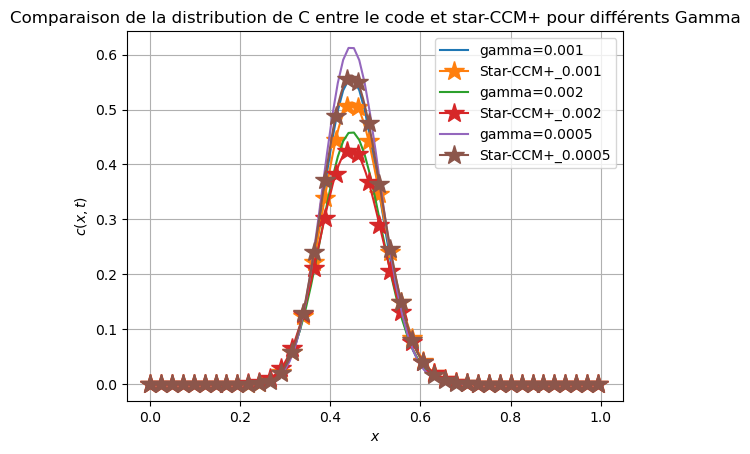

In [85]:
#affichage des 3 courbes en fonction de la valeur de gamma
cfd4,N4=cfd1(1,1,84,84,0.25,10**(-3),0.1,0.2,0.5,1,0,1) #essais pour se rapprocher du résultat StarCCM+ en variant le dt et le maillage
cfd5,N5=cfd1(1,1,84,84,0.25,2*10**(-3),0.1,0.2,0.5,1,0,1) #avec U0=0,5 m/s
cfd6,N6=cfd1(1,1,84,84,0.25,5*10**(-4),0.1,0.2,0.5,1,0,1)
afficher4(cfd4,N4,1,1,84,84,cfd5,cfd6)